# Exploratory Data Analysis

##### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Change to the relative path of the folder where the csv files are saved
processed_folder = f"{os.path.dirname(os.path.normpath(os.getcwd()))}/data/processed"

##### Styling

In [3]:
FORCES = [
    'Devon & Cornwall Police',
    'Metropolitan Police Service',
    'North Yorkshire Police',
    'South Wales Police',
    'Thames Valley Police'
]
PALETTE = [
    '#f02d75',
    '#498ad4',
    '#f5a300',
    '#7bb12f',
    '#6d2bde'
]
FORCE_COLOURS = dict(zip(FORCES, PALETTE))

##### Load and Validate CSVs

Loading and Validating CSVs, attach Year 1/Year 2 labels, and merging population data.

In [4]:
crime_df = pd.read_csv(f"{processed_folder}/crime_master.csv", parse_dates=['Month'])

C:\Users\HP\AppData\Local\Temp\ipykernel_13980\1091883738.py:1: DtypeWarning: Columns (0,10) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_df = pd.read_csv(f"{processed_folder}/crime_master.csv", parse_dates=['Month'])


In [5]:
crime_df.shape
crime_df.info()
crime_df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3281512 entries, 0 to 3281511
Data columns (total 15 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Crime ID               object        
 1   Month                  datetime64[ns]
 2   Reported by            object        
 3   Falls within           object        
 4   Longitude              float64       
 5   Latitude               float64       
 6   Location               object        
 7   LSOA code              object        
 8   LSOA name              object        
 9   Crime type             object        
 10  Last outcome category  object        
 11  Has_Coordinates        bool          
 12  Missing_Crime_ID       bool          
 13  No_Outcome             bool          
 14  analysis_year          object        
dtypes: bool(3), datetime64[ns](1), float64(2), object(9)
memory usage: 309.8+ MB


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Has_Coordinates,Missing_Crime_ID,No_Outcome,analysis_year
2597071,f91e7fe5fdee2b691c0b3e8b2285e6f4dc8e7bcead53cc...,2024-07-01,Metropolitan Police Service,Metropolitan Police Service,-0.059632,51.560723,On or near Ickburgh Road,E01001767,Hackney 010D,Other theft,Investigation complete; no suspect identified,True,False,False,Year 2
1512618,91158e61b494189c3b511a7a2d04d9aeaeb3e705b2f6a8...,2024-06-01,Metropolitan Police Service,Metropolitan Police Service,-0.483548,51.483080,On or near Prison,E01002444,Hillingdon 031A,Violence and sexual offences,Investigation complete; no suspect identified,True,False,False,Year 2
1714387,a466d9b468fc0c077cf617e3c62b14a7e7b415105f4988...,2023-11-01,Metropolitan Police Service,Metropolitan Police Service,0.082776,51.534091,On or near Ketch Street,E01000051,Barking and Dagenham 021D,Violence and sexual offences,Investigation complete; no suspect identified,True,False,False,Year 1
2529056,f297ddd493475e9e3ee2e25a9fda79c85e9fbcbd746b55...,2024-11-01,Devon & Cornwall Police,Devon & Cornwall Police,NaN,NaN,No Location,NaN,NaN,Criminal damage and arson,Investigation complete; no suspect identified,False,False,False,Year 2
1108914,6a5d32a65c050680c1e4d8ada27d65f7a8afda401a9f1a...,2023-09-01,Metropolitan Police Service,Metropolitan Police Service,-0.165407,51.461115,On or near Hafer Road,E01004552,Wandsworth 008C,Violence and sexual offences,Investigation complete; no suspect identified,True,False,False,Year 1


In [6]:
# Useful for Time Series Analysis
crime_df['Year'] = crime_df['Month'].dt.year
crime_df['Month No'] = crime_df['Month'].dt.month
crime_df['Month Name'] = crime_df['Month'].dt.strftime('%b %Y')

Loading and Merging Population Data

In [7]:
pop_df = pd.read_csv(f"{processed_folder}/population_master.csv")

In [8]:
pop_df.info()
pop_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   force             10 non-null     object
 1   mid_year          10 non-null     int64 
 2   Total Population  10 non-null     int64 
 3   analysis_year     10 non-null     object
dtypes: int64(2), object(2)
memory usage: 452.0+ bytes


,force,mid_year,Total Population,analysis_year
0,Metropolitan Police,2023,8986099,Year 1
1,Metropolitan Police,2024,9074625,Year 2
2,North Yorkshire,2023,835592,Year 1
3,North Yorkshire,2024,844571,Year 2
4,Thames Valley,2023,2600732,Year 1
5,Thames Valley,2024,2640201,Year 2
6,Devon & Cornwall,2023,1825690,Year 1
7,Devon & Cornwall,2024,1840161,Year 2
8,South Wales,2023,1353346,Year 1
9,South Wales,2024,1363561,Year 2


In [9]:
# Standardising Force Names to match crime_df Falls Within Column
pop_df = pop_df.rename(columns={'force': 'Falls within'})

In [10]:
pop_df['Falls within'] = pop_df['Falls within'].map({
    'Metropolitan Police': 'Metropolitan Police Service',
    'North Yorkshire': 'North Yorkshire Police',
    'Thames Valley': 'Thames Valley Police',
    'Devon & Cornwall': 'Devon & Cornwall Police',
    'South Wales': 'South Wales Police' 
})

##### Dataset Overview

In [11]:
# Creating Summary Statistics about data quality
summary = (
    crime_df.groupby('Falls within').agg(
        Total_Crimes=('Crime ID', 'count'),
        Missing_ID_Pct=('Missing_Crime_ID', 'mean'),
        No_Outcome_Pct=('No_Outcome', 'mean'),
        Has_Coords_Pct=('Has_Coordinates', 'mean'),
    ).reset_index()
)
summary['Missing_ID_Pct'] = (summary['Missing_ID_Pct'] * 100).round(2)
summary['No_Outcome_Pct'] = (summary['No_Outcome_Pct'] * 100).round(2)
summary['Has_Coords_Pct'] = (summary['Has_Coords_Pct'] * 100).round(2)
summary = summary.sort_values(['Total_Crimes'], ascending=False)
summary

,Falls within,Total_Crimes,Missing_ID_Pct,No_Outcome_Pct,Has_Coords_Pct
1,Metropolitan Police Service,1778572,20.43,20.43,99.04
4,Thames Valley Police,364281,9.31,9.31,97.76
3,South Wales Police,229804,14.91,14.91,97.65
0,Devon & Cornwall Police,200780,19.51,19.51,94.98
2,North Yorkshire Police,95514,23.70,23.70,99.35


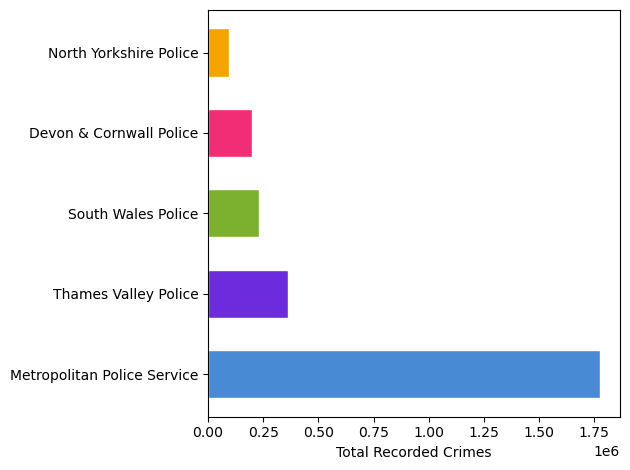

In [12]:
# Total Crimes by Force
fig, ax = plt.subplots()

colours = [FORCE_COLOURS[f] for f in summary['Falls within']]
bars = ax.barh(
    summary['Falls within'],
    summary['Total_Crimes'],
    color=colours, 
    edgecolor='white', 
    height=0.6
)

ax.set_xlabel('Total Recorded Crimes')
plt.tight_layout()
plt.show()

##### Crime Volume and Trends over Time

In [13]:
# Dataset grouped by month
monthly = (
    crime_df.groupby(['Month', 'Falls within'])
    .size()
    .reset_index(name='Crime Count')
)

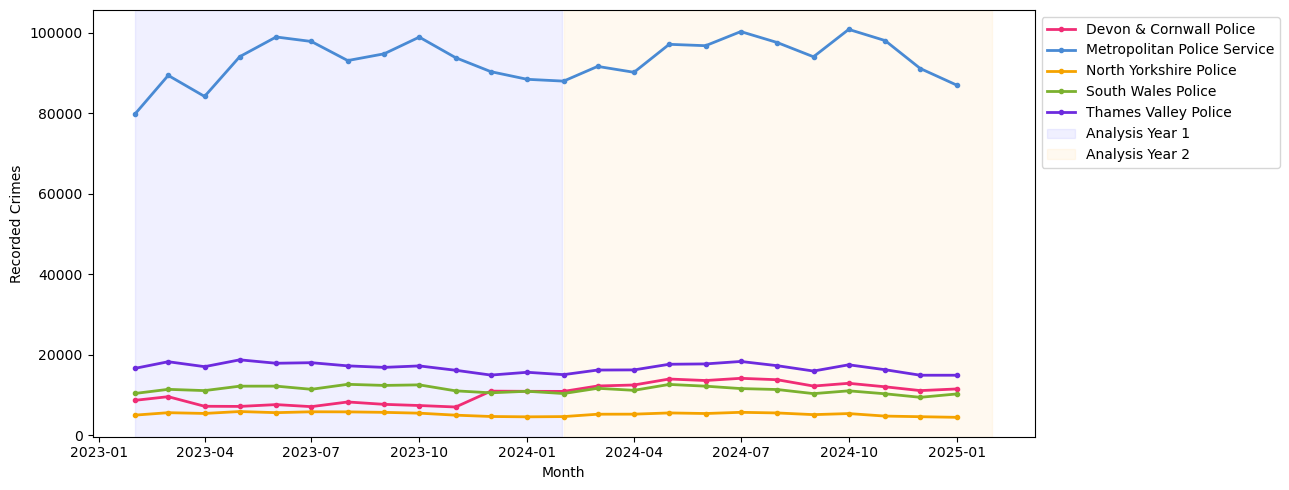

In [14]:
# Monthly Crime Volume by Police Force
fig, ax = plt.subplots(figsize=(13, 5))

for force in FORCES:
    sub = monthly[monthly['Falls within'] == force].sort_values('Month')
    ax.plot(
        sub['Month'],
        sub['Crime Count'],
        label=force,
        color=FORCE_COLOURS[force],
        linewidth=2,
        marker='o',
        markersize=3
    )

# Shaded year bands
ax.axvspan(
    pd.Timestamp('2023-02-01'),
    pd.Timestamp('2024-01-31'),
    alpha=0.06,
    color='blue',
    label='Analysis Year 1'
)
ax.axvspan(
    pd.Timestamp('2024-02-01'),
    pd.Timestamp('2025-01-31'),
    alpha=0.06,
    color='orange',
    label='Analysis Year 2'
)

ax.set_xlabel('Month')
ax.set_ylabel('Recorded Crimes')
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

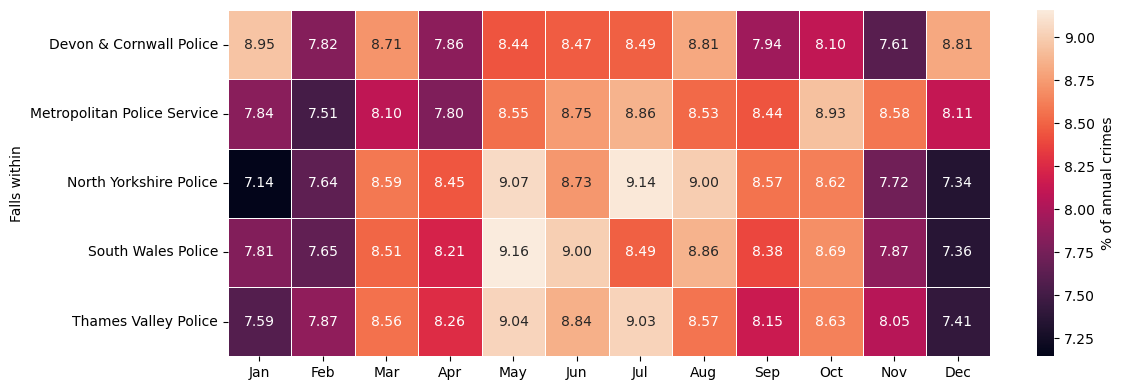

In [15]:
# Crime Seasonality Heatmap (% of annual total per month) 
heat_data = (
    crime_df.groupby(['Falls within', 'Month No'])
    .size()
    .reset_index(name='Count')
    .pivot(index='Falls within', columns='Month No', values='Count')
)

FULL_MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heat_data.columns = [FULL_MONTH_LABELS[c-1] for c in heat_data.columns]

# Normalising heatmap data across rows to ensure that the size differences in forces
# doesn't skew the heatmap
heat_norm = heat_data.div(heat_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    heat_norm,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    cmap='rocket',
    ax=ax,
    cbar_kws={'label': '% of annual crimes'}
)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

##### Crime Type Distribution


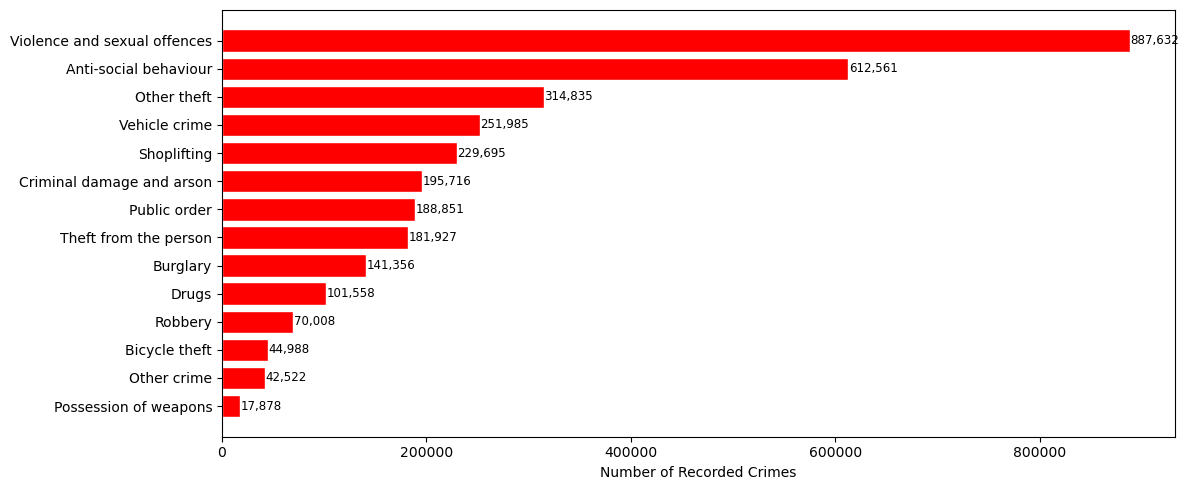

In [16]:
# Crime Types Across All Forces
crime_types = (
    crime_df['Crime type'].value_counts().reset_index()
)
crime_types.columns = ['Crime type', 'Count']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    crime_types['Crime type'][::-1],
    crime_types['Count'][::-1],
    edgecolor='white',
    color='red'
)

for bar, val in zip(bars, crime_types['Count'][::-1]):
    ax.text(
        val + 500,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center',
        fontsize=8.5
    )

ax.set_xlabel('Number of Recorded Crimes')
plt.tight_layout()
plt.show()

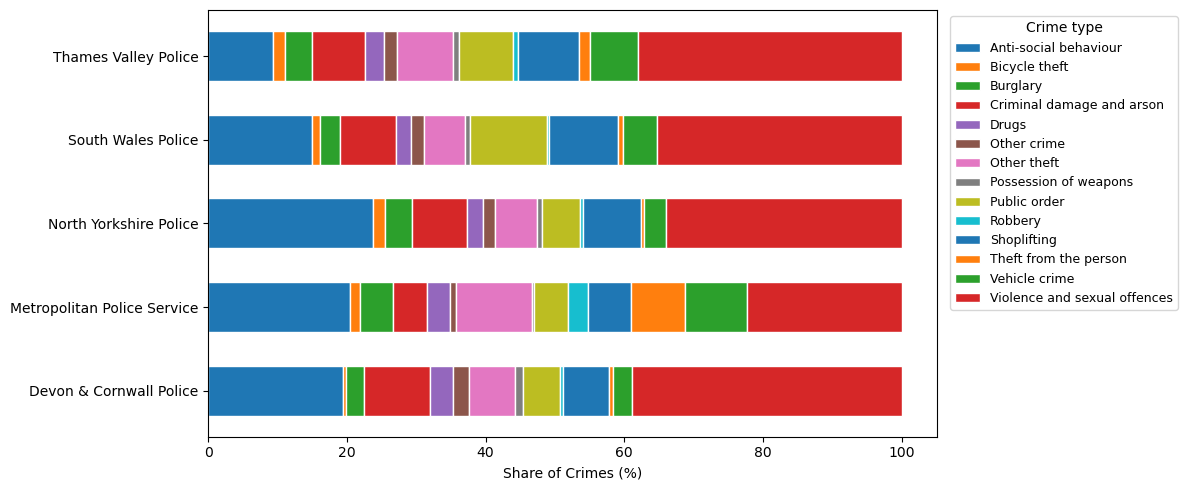

In [17]:
# ── Fig 4.2 — Crime type share per force (stacked 100% bar) ──────────────────
crime_type_force = (
    crime_df.groupby(['Falls within', 'Crime type'])
    .size()
    .reset_index(name='Count')
)

ct_pivot = crime_type_force.pivot(
    index='Falls within',
    columns='Crime type',
    values='Count'
).fillna(0)

ct_pct = ct_pivot.div(ct_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ct_pct.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    edgecolor='white',
    width=0.6)

ax.set_xlabel('Share of Crimes (%)')
ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9,
    title='Crime type')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

##### Last Outcomes Analysis

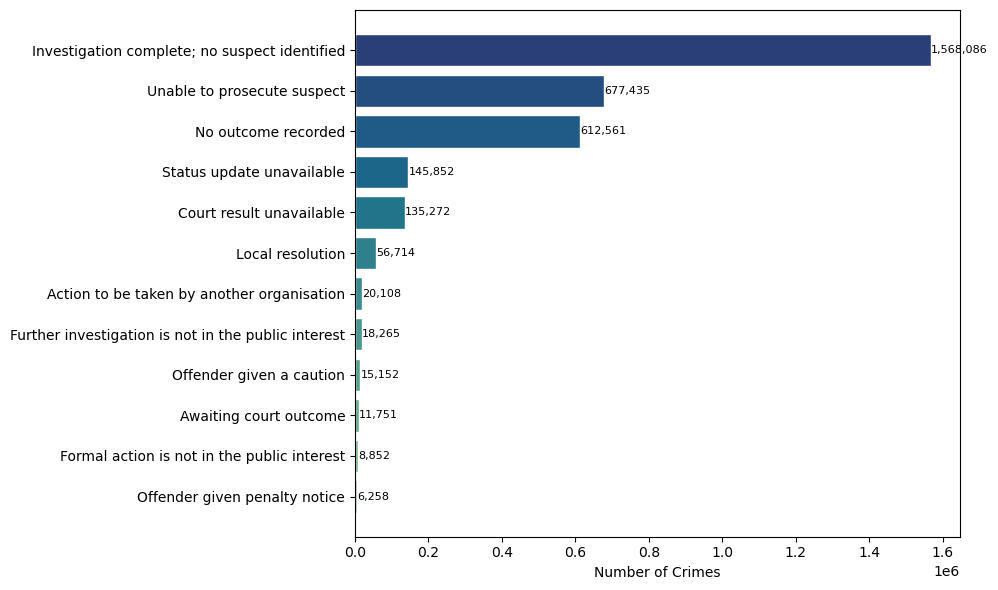

In [18]:
# Top 12 Outcome Categories by each Police Force
top_outcomes = (
    crime_df['Last outcome category']
    .fillna('No outcome recorded')
    .value_counts()
    .head(12)
    .reset_index()
)
top_outcomes.columns = ['Outcome', 'Count']

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('crest', len(top_outcomes))
ax.barh(
    top_outcomes['Outcome'][::-1],
    top_outcomes['Count'][::-1],
    color=palette,
    edgecolor='white'
)

for bar, val in zip(ax.patches, top_outcomes['Count'][::-1]):
    ax.text(
        val + 200,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center',
        fontsize=8
    )

ax.set_xlabel('Number of Crimes')
plt.tight_layout()
plt.show()

##### Population Adjusted Analysis

In [19]:
# Calculating Crime per 1,000 residents
crime_counts = (
    crime_df.groupby(['Falls within', 'analysis_year'])
    .size()
    .reset_index(name='Crime Count')
)

crime_pop = crime_counts.merge(pop_df, on=['Falls within', 'analysis_year'])
crime_pop['Crimes per 1,000'] = (crime_pop['Crime Count'] / crime_pop['Total Population'] * 1000).round(2)

crime_pop[[
    'Falls within',
    'analysis_year',
    'Crime Count',
    'Total Population',
    'Crimes per 1,000'
]].sort_values(['Falls within', 'analysis_year'])

,Falls within,analysis_year,Crime Count,Total Population,"Crimes per 1,000"
0,Devon & Cornwall Police,Year 1,99071,1825690,54.26
1,Devon & Cornwall Police,Year 2,150382,1840161,81.72
2,Metropolitan Police Service,Year 1,1103109,8986099,122.76
3,Metropolitan Police Service,Year 2,1132030,9074625,124.75
4,North Yorkshire Police,Year 1,64070,835592,76.68
5,North Yorkshire Police,Year 2,61112,844571,72.36
6,South Wales Police,Year 1,138249,1353346,102.15
7,South Wales Police,Year 2,131821,1363561,96.67
8,Thames Valley Police,Year 1,204151,2600732,78.50
9,Thames Valley Police,Year 2,197517,2640201,74.81


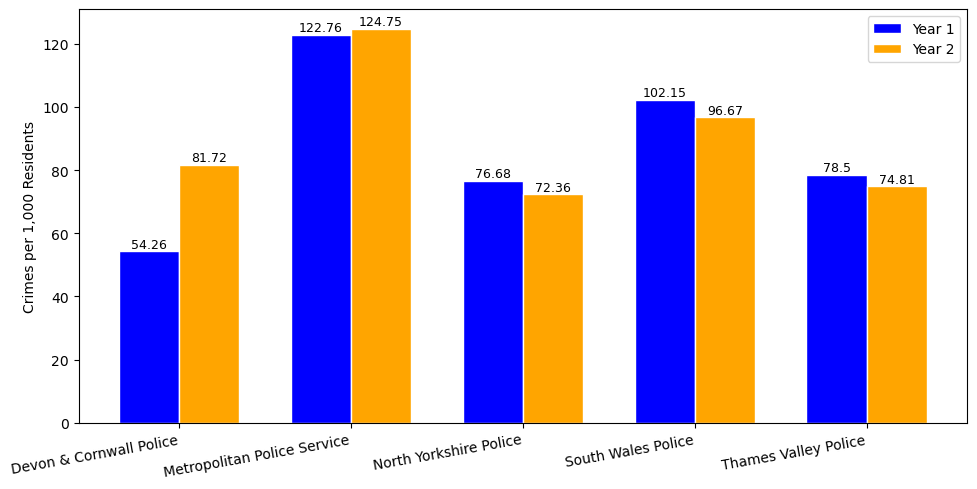

In [20]:
# Crimes per 1,000 residents by force & year
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(FORCES))
width = 0.35
years = crime_pop['analysis_year'].unique()
bar_colours = ['blue', 'orange']

for j, (yr, colour) in enumerate(zip(years, bar_colours)):
    vals = [crime_pop[
        (crime_pop['Falls within'] == f) & (crime_pop['analysis_year']==yr)
        ]
        ['Crimes per 1,000'].values[0] for f in FORCES]
    bars = ax.bar(
        x + (j-0.5) * width,
        vals, 
        width,
        label=yr.split('(')[0].strip(),
        color=colour,
        edgecolor='white'
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.2,
            f'{v}', 
            ha='center',
            va='bottom',
            fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(FORCES, rotation=10, ha='right')
ax.set_ylabel('Crimes per 1,000 Residents')
ax.legend()
plt.tight_layout()
plt.show()

Geographic Scatter Maps

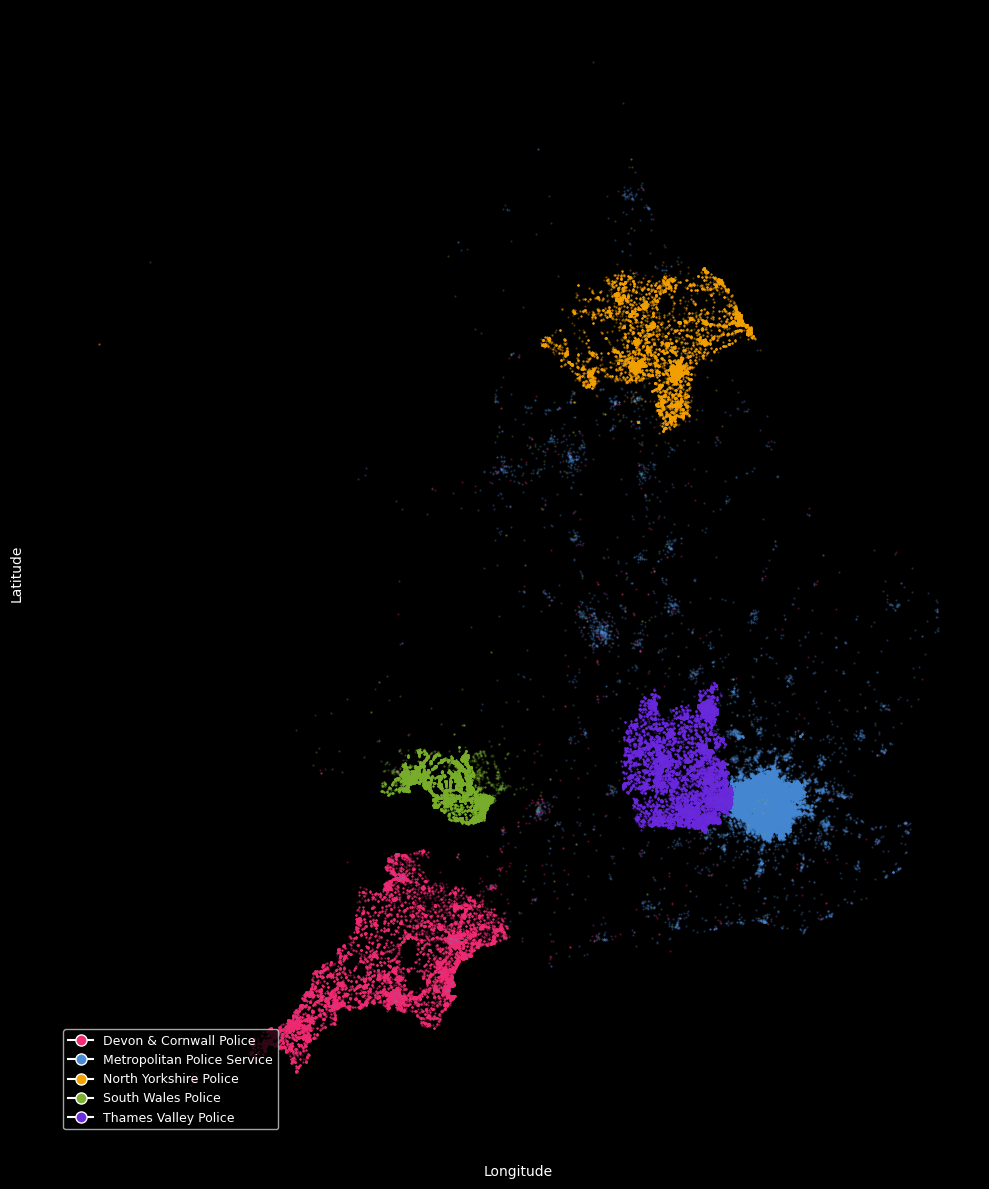

In [21]:
geo = crime_df[crime_df['Has_Coordinates']]

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

for force in FORCES:
    sub = geo[geo['Falls within'] == force]
    ax.scatter(
        sub['Longitude'],
        sub['Latitude'],
        s=0.3,
        alpha=0.3,
        color=FORCE_COLOURS[force],
        label=force
    )

legend_handles = [
    matplotlib.lines.Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=FORCE_COLOURS[f],
        markersize=8,
        label=f)
    for f in FORCES
]
ax.legend(
    handles=legend_handles,
    loc='lower left',
    framealpha=0.8,
    facecolor='black',
    labelcolor='white',
    fontsize=9)

ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.tick_params()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

##### Crime Type Categorised

In [22]:
# Shoplifting not inlcuded in property crimes, while shoplifting is a property crime it's not
# of primary danger to a potential home owner in as much as the shop lifters are not violent
PROPERTY_CRIMES = ['Burglary', 'Vehicle crime', 'Robbery', 'Theft from the person', 'Bicycle theft', 'Criminal damage and arson', 'Other theft']
VIOLENT_CRIMES = ['Violence and sexual offences', 'Possession of weapons']
ANTISOCIAL = ['Anti-social behaviour', 'Public order']
DRUG_CRIMES = ['Drugs']

def categorise_impact(crime_type):
    if crime_type in PROPERTY_CRIMES:
        return 'Property Crime'
    elif crime_type in VIOLENT_CRIMES:
        return 'Violent Crime'
    elif crime_type in ANTISOCIAL:
        return 'Anti-Social Behaviour'
    elif crime_type in DRUG_CRIMES:
        return 'Drug Crime'
    return 'Other'

crime_df['Crime Impact Category'] = crime_df['Crime type'].apply(categorise_impact)

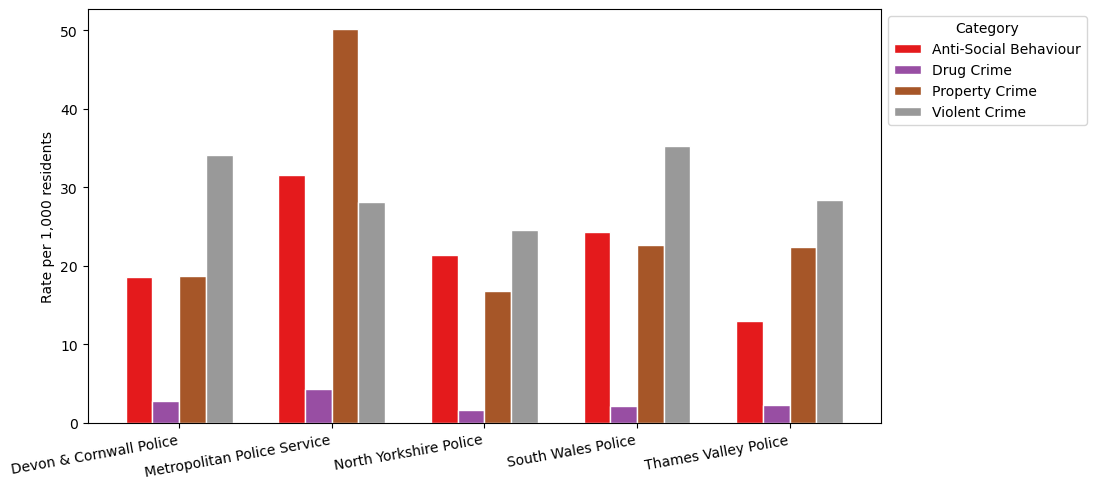

In [23]:
# Real Estate Relevant crime rates per 1,000 by force
re_cats = ['Property Crime', 'Violent Crime', 'Anti-Social Behaviour', 'Drug Crime']

re_data = (
    crime_df[crime_df['Crime Impact Category'].isin(re_cats)]
    .groupby(['Falls within', 'analysis_year', 'Crime Impact Category'])
    .size()
    .reset_index(name='Count')
    .merge(pop_df, on=['Falls within', 'analysis_year'])
)
re_data['Rate per 1k'] = re_data['Count'] / re_data['Total Population'] * 1000

re_y2 = re_data[re_data['analysis_year'] == 'Year 2']
re_pivot = re_y2.pivot(
    index='Falls within',
    columns='Crime Impact Category',
    values='Rate per 1k'
).fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
re_pivot.plot(
    kind='bar',
    ax=ax,
    colormap='Set1',
    edgecolor='white',
    width=0.7
)
ax.set_xlabel('')
ax.set_xticklabels(re_pivot.index, rotation=10, ha='right')
ax.set_ylabel('Rate per 1,000 residents')
ax.legend(title='Category', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()